In [3]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# 1. 參數設定 (請務必確認路徑)
# =========================================================
# 根據 0409 檔案，AR5 資料通常放在這個結構下
base_dir = Path(r"C:\AR5_統計降尺度_日資料_臺北市_平均溫") 
target_lat = 24.9  
target_lon = 121.5

# 蟑螂世代數參數 (參考 0407 檔案)
T_BASE = 10.4      
K_THRESHOLD = 3250  
TARGET_YEARS = range(2004, 2037)

# =========================================================
# 2. 搜尋與計算邏輯
# =========================================================
all_results = []

print(f"開始掃描路徑: {base_dir}")

# 遍歷模式資料夾 (如: ACCESS1-0, BCC-CSM1-1...)
if not base_dir.exists():
    print(f"錯誤：找不到路徑 {base_dir}，請檢查路徑設定。")
else:
    for model_path in base_dir.iterdir():
        if model_path.is_dir():
            model_name = model_path.name
            
            # 遍歷情境 (如: historical, rcp26, rcp45, rcp85)
            for rcp_path in model_path.iterdir():
                if rcp_path.is_dir():
                    rcp_scenario = rcp_path.name
                    
                    # 搜尋包含 tmean 的 CSV 檔案
                    # 注意：AR5 的檔名可能包含格點資訊，這裡用 glob 搜尋
                    files = list(rcp_path.glob("*tmean*.csv"))
                    
                    for f in files:
                        try:
                            # 讀取資料
                            df = pd.read_csv(f)
                            
                            # 轉換時間 (處理 AR5 可能的日期格式)
                            df['date'] = pd.to_datetime(df['date'])
                            
                            # 篩選時間區間
                            mask = (df['date'].dt.year >= 2004) & (df['date'].dt.year <= 2036)
                            df_period = df.loc[mask].copy()
                            
                            if df_period.empty:
                                continue
                            
                            # 計算世代數
                            # DD = max(Tmean - 10.4, 0)
                            df_period['dd'] = np.maximum(df_period['tmean'] - T_BASE, 0)
                            
                            # 按年加總 DD / 3250
                            annual_gen = df_period.groupby(df_period['date'].dt.year)['dd'].sum() / K_THRESHOLD
                            
                            # 轉換為 DataFrame 儲存
                            res_df = annual_gen.reset_index()
                            res_df.columns = ['year', 'generation_count']
                            res_df['model'] = model_name
                            res_df['scenario'] = rcp_scenario
                            
                            all_results.append(res_df)
                            print(f"[成功] 抓取模式: {model_name} | 情境: {rcp_scenario}")
                            
                        except Exception as e:
                            print(f"[失敗] 檔案 {f.name}: {e}")

# =========================================================
# 3. 合併結果
# =========================================================
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    print("\n--- 所有資料抓取完成 ---")
    print(final_df.head())
    
    # 計算 Ensemble Mean (不分情境，呈現所有模式在同一時間軸的變化)
    ensemble_mean = final_df.groupby('year')['generation_count'].mean()
    print("\nEnsemble Mean 計算完成。")
else:
    print("\n[警告] 未能抓取到任何資料。請確認：")
    print(f"1. {base_dir} 內是否有模式資料夾？")
    print(f"2. CSV 檔名是否包含 'tmean' 字眼？")
    print(f"3. 檔案中的日期是否涵蓋 2004-2036？")

開始掃描路徑: C:\AR5_統計降尺度_日資料_臺北市_平均溫

[警告] 未能抓取到任何資料。請確認：
1. C:\AR5_統計降尺度_日資料_臺北市_平均溫 內是否有模式資料夾？
2. CSV 檔名是否包含 'tmean' 字眼？
3. 檔案中的日期是否涵蓋 2004-2036？


正在掃描 11256 個檔案...
資料抓取完成，已存至 ar5_cockroach_generations_2004_2036.csv


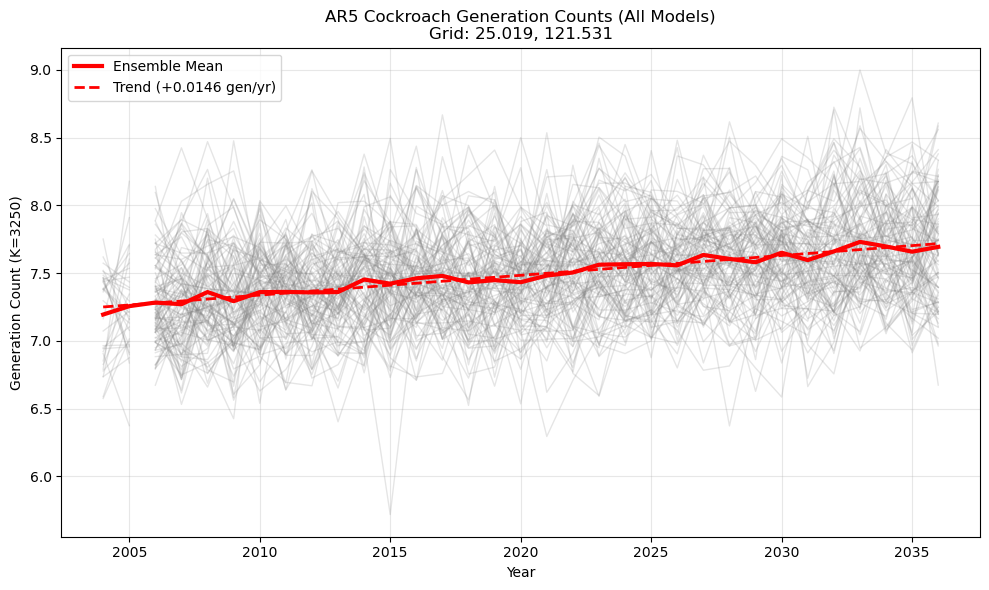

In [7]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# =========================================================
# 1. 參數設定
# =========================================================
# 請修改為你存放 AR5 平均溫 CSV 的資料夾路徑
base_dir = Path(r"C:\AR5_統計降尺度_日資料_臺北市_平均溫") 

# 蟑螂發育參數
T_BASE = 10.4      
K_THRESHOLD = 650  
START_YEAR = 2004
END_YEAR = 2036

# 指定格點 (大學里)
POI_LAT = 25.0190099143756
POI_LON = 121.53137177116402

# =========================================================
# 2. 資料抓取與計算函數
# =========================================================
def process_ar5_files(data_dir):
    results = []
    # 檔名解析正則表達式
    pattern = re.compile(r"平均溫_(?P<scenario>historical|rcp\d+)_(?P<model>.+?)_(?P<year>\d{4})\.csv")
    
    files = list(data_dir.glob("*.csv"))
    print(f"正在掃描 {len(files)} 個檔案...")

    for f in files:
        match = pattern.search(f.name)
        if match:
            meta = match.groupdict()
            year = int(meta['year'])
            
            if START_YEAR <= year <= END_YEAR:
                try:
                    df = pd.read_csv(f)
                    # 1. 尋找最近格點
                    df['dist'] = np.sqrt((df['LAT'] - POI_LAT)**2 + (df['LON'] - POI_LON)**2)
                    row = df.loc[df['dist'].idxmin()]
                    
                    # 2. 提取日期欄位 (格式為 8 位數字)
                    date_cols = [c for c in df.columns if re.fullmatch(r"\d{8}", str(c))]
                    temps = pd.to_numeric(row[date_cols], errors='coerce')
                    
                    # 3. 計算該年世代數
                    dd_sum = np.maximum(temps - T_BASE, 0).sum()
                    gen_count = dd_sum / K_THRESHOLD
                    
                    results.append({
                        'model': meta['model'],
                        'scenario': meta['scenario'],
                        'year': year,
                        'gen_count': gen_count
                    })
                except Exception as e:
                    print(f"處理檔案 {f.name} 出錯: {e}")
                    
    return pd.DataFrame(results)

# =========================================================
# 3. 執行抓取
# =========================================================
final_df = process_ar5_files(base_dir)

if not final_df.empty:
    # 儲存計算結果
    final_df.to_csv("ar5_cockroach_generations_2004_2036.csv", index=False, encoding='utf-8-sig')
    print("資料抓取完成，已存至 ar5_cockroach_generations_2004_2036.csv")
    
    # 資料整理：將每個 (模式+情境) 視為一條獨立線
    final_df['id'] = final_df['model'] + "_" + final_df['scenario']
    pivot_df = final_df.pivot_table(index='year', columns='id', values='gen_count')
    ensemble_mean = pivot_df.mean(axis=1)

    # =========================================================
    # 4. 繪圖 (參考 ACCESS-CM2_dd.png 風格)
    # =========================================================
    plt.figure(figsize=(10, 6))
    
    # 灰色細線：所有模式與情境
    for col in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[col], color='gray', alpha=0.2, linewidth=1)
    
    # 紅色粗線：所有模式平均
    plt.plot(ensemble_mean.index, ensemble_mean, color='red', linewidth=3, label='Ensemble Mean')
    
    # 計算並畫出趨勢線
    slope, intercept, r, p, std = stats.linregress(ensemble_mean.index, ensemble_mean.values)
    plt.plot(ensemble_mean.index, slope * ensemble_mean.index + intercept, 
             color='red', linestyle='--', linewidth=2, label=f'Trend ({slope:+.4f} gen/yr)')

    plt.title(f'AR5 Cockroach Generation Counts (All Models)\nGrid: {POI_LAT:.3f}, {POI_LON:.3f}')
    plt.xlabel('Year')
    plt.ylabel('Generation Count (K=3250)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("AR5_all_models_generation_count.png", dpi=300)
    plt.show()

else:
    print("未抓取到任何資料，請檢查路徑與年份設定。")